In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

API_KEY = "ea4290d47cdddf46e717de0f92b5503f96adc1aa667a7720cc8e1bb821316752"
headers = {"X-API-Key": API_KEY}

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Check sensor response
url = f"https://api.openaq.org/v3/locations/8118/sensors"
response = requests.get(url, headers=headers)
print(response.status_code)
print(response.json())

200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 100, 'found': 1}, 'results': [{'id': 23534, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}, 'datetimeFirst': {'utc': '2016-11-09T19:00:00Z', 'local': '2016-11-10T00:30:00+05:30'}, 'datetimeLast': {'utc': '2026-06-19T05:30:00Z', 'local': '2026-06-19T11:00:00+05:30'}, 'coverage': {'expectedCount': 1, 'expectedInterval': '01:00:00', 'observedCount': 78035, 'observedInterval': '78035:00:00', 'percentComplete': 7803500.0, 'percentCoverage': 7803500.0, 'datetimeFrom': {'utc': '2016-11-09T19:00:00Z', 'local': '2016-11-10T00:30:00+05:30'}, 'datetimeTo': {'utc': '2026-06-19T05:30:00Z', 'local': '2026-06-19T11:00:00+05:30'}}, 'latest': {'datetime': {'utc': '2026-06-19T05:30:00Z', 'local': '2026-06-19T11:00:00+05:30'}, 'value': 55.0, 'coordinates': {'latitude': 28.63576, 'longitude': 77.22445}}, 'summary': {'min': -999.0, 'q02': None, 'q25': None, 'median': None, 'q75': 

In [5]:
# Check measurements response
sensor_id = 23534
meas_url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {
    'limit': 10,
    'page': 1
}
response = requests.get(meas_url, headers=headers, params=params)
print(response.status_code)
print(response.json())

200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 10, 'found': '>10'}, 'results': [{'value': 270.0, 'flagInfo': {'hasFlags': False}, 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None}, 'period': {'label': 'raw', 'interval': '01:00:00', 'datetimeFrom': {'utc': '2016-11-09T17:30:00Z', 'local': '2016-11-09T23:00:00+05:30'}, 'datetimeTo': {'utc': '2016-11-09T18:30:00Z', 'local': '2016-11-10T00:00:00+05:30'}}, 'coordinates': None, 'summary': None, 'coverage': {'expectedCount': 1, 'expectedInterval': '01:00:00', 'observedCount': 1, 'observedInterval': '01:00:00', 'percentComplete': 100.0, 'percentCoverage': 100.0, 'datetimeFrom': {'utc': '2016-11-09T17:30:00Z', 'local': '2016-11-09T23:00:00+05:30'}, 'datetimeTo': {'utc': '2016-11-09T18:30:00Z', 'local': '2016-11-10T00:00:00+05:30'}}}, {'value': 297.0, 'flagInfo': {'hasFlags': False}, 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None}, 'period': {'label': 'raw', 'inte

In [6]:
import time

# Indian cities with their sensor IDs
cities = {
    'New Delhi': 23534,
    'Mumbai': 23570,
    'Kolkata': 23558,
    'Chennai': 23540,
    'Bangalore': 23522
}

def fetch_city_data(city_name, sensor_id, pages=50):
    all_data = []
    
    for page in range(1, pages+1):
        url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
        params = {'limit': 1000, 'page': page}
        
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
        
        if 'results' not in data or not data['results']:
            break
        
        for record in data['results']:
            all_data.append({
                'city': city_name,
                'datetime': record['period']['datetimeTo']['utc'],
                'pm25': record['value']
            })
        
        print(f"{city_name} - Page {page}: {len(data['results'])} records")
        time.sleep(0.5)  # avoid rate limiting
        
        if len(data['results']) < 1000:
            break
    
    return all_data

# Fetch Delhi first
all_records = []
records = fetch_city_data('New Delhi', 23534, pages=50)
all_records.extend(records)
print(f"\nDelhi total: {len(records)} records")

New Delhi - Page 1: 1000 records
New Delhi - Page 2: 1000 records
New Delhi - Page 3: 1000 records
New Delhi - Page 4: 1000 records
New Delhi - Page 5: 1000 records
New Delhi - Page 6: 1000 records
New Delhi - Page 7: 1000 records

Delhi total: 7000 records


In [7]:
# Find sensor IDs for all cities
city_locations = {
    'Mumbai': 8172,
    'Kolkata': 8159,
    'Chennai': 8123,
    'Bangalore': 8107
}

for city, location_id in city_locations.items():
    url = f"https://api.openaq.org/v3/locations/{location_id}/sensors"
    response = requests.get(url, headers=headers)
    data = response.json()
    print(f"\n{city}:")
    print(data)
    time.sleep(0.5)


Mumbai:
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 100, 'found': 1}, 'results': [{'id': 5077640, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}, 'datetimeFirst': {'utc': '2022-10-03T20:00:00Z', 'local': '2022-10-04T01:30:00+05:30'}, 'datetimeLast': {'utc': '2025-03-04T11:30:00Z', 'local': '2025-03-04T17:00:00+05:30'}, 'coverage': {'expectedCount': 1, 'expectedInterval': '01:00:00', 'observedCount': 17656, 'observedInterval': '17656:00:00', 'percentComplete': 1765600.0, 'percentCoverage': 1765600.0, 'datetimeFrom': {'utc': '2022-10-03T20:00:00Z', 'local': '2022-10-04T01:30:00+05:30'}, 'datetimeTo': {'utc': '2025-03-04T11:30:00Z', 'local': '2025-03-04T17:00:00+05:30'}}, 'latest': {'datetime': {'utc': '2025-03-04T11:30:00Z', 'local': '2025-03-04T17:00:00+05:30'}, 'value': -999.0, 'coordinates': {'latitude': 22.56263, 'longitude': 88.36304}}, 'summary': {'min': -999.0, 'q02': None, 'q25': None, 'median': None

In [8]:
cities = {
    'New Delhi': 23534,
    'Mumbai': 5077640,
    'Kolkata': 23751
}

all_records = []

for city_name, sensor_id in cities.items():
    print(f"\nFetching {city_name}...")
    records = fetch_city_data(city_name, sensor_id, pages=78)
    all_records.extend(records)
    print(f"{city_name} total: {len(records)} records")
    time.sleep(1)

print(f"\nTotal records: {len(all_records)}")


Fetching New Delhi...
New Delhi - Page 1: 1000 records
New Delhi - Page 2: 1000 records
New Delhi - Page 3: 1000 records
New Delhi - Page 4: 1000 records
New Delhi - Page 5: 1000 records
New Delhi - Page 6: 1000 records
New Delhi - Page 7: 1000 records
New Delhi total: 7000 records

Fetching Mumbai...
Mumbai - Page 1: 1000 records
Mumbai - Page 2: 1000 records
Mumbai - Page 3: 1000 records
Mumbai - Page 4: 1000 records
Mumbai - Page 5: 1000 records
Mumbai - Page 6: 1000 records
Mumbai - Page 7: 1000 records
Mumbai - Page 8: 1000 records
Mumbai - Page 9: 1000 records
Mumbai - Page 10: 1000 records
Mumbai - Page 11: 1000 records
Mumbai - Page 12: 1000 records
Mumbai total: 12000 records

Fetching Kolkata...
Kolkata - Page 1: 1000 records
Kolkata - Page 2: 1000 records
Kolkata - Page 3: 1000 records
Kolkata - Page 4: 1000 records
Kolkata - Page 5: 1000 records
Kolkata - Page 6: 1000 records
Kolkata - Page 7: 1000 records
Kolkata - Page 8: 1000 records
Kolkata - Page 9: 1000 records
Kolka

In [9]:
# Convert to DataFrame
df = pd.DataFrame(all_records)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Remove invalid readings (-999 values)
df = df[df['pm25'] > 0]
df = df[df['pm25'] < 1000]

print(df.shape)
print(df.head())
print(df['city'].value_counts())

(32803, 3)
        city                  datetime   pm25
0  New Delhi 2016-11-09 18:30:00+00:00  270.0
1  New Delhi 2016-11-09 19:30:00+00:00  297.0
2  New Delhi 2016-11-09 20:30:00+00:00  306.5
3  New Delhi 2016-11-09 21:30:00+00:00  308.7
4  New Delhi 2016-11-09 22:30:00+00:00  315.3
city
Kolkata      15276
Mumbai       11277
New Delhi     6250
Name: count, dtype: int64


In [10]:
# Fetch more Delhi data (pages 8 to 78)
print("Fetching more Delhi data...")
more_delhi = []

for page in range(8, 79):
    url = f"https://api.openaq.org/v3/sensors/23534/measurements"
    params = {'limit': 1000, 'page': page}
    
    response = requests.get(url, headers=headers, params=params)
    data = response.json()
    
    if 'results' not in data or not data['results']:
        print(f"Stopped at page {page}")
        break
    
    for record in data['results']:
        more_delhi.append({
            'city': 'New Delhi',
            'datetime': record['period']['datetimeTo']['utc'],
            'pm25': record['value']
        })
    
    print(f"Page {page}: {len(data['results'])} records")
    time.sleep(0.5)
    
    if len(data['results']) < 1000:
        break

print(f"\nAdditional Delhi records: {len(more_delhi)}")


Fetching more Delhi data...
Stopped at page 8

Additional Delhi records: 0


In [11]:
# Search for more Indian locations with PM2.5
url = "https://api.openaq.org/v3/locations"
params = {
    'country_id': 100,  # India
    'parameters_id': 2,  # PM2.5
    'limit': 100
}

response = requests.get(url, headers=headers, params=params)
data = response.json()

print(f"Total Indian PM2.5 locations found: {data['meta']['found']}")
for loc in data['results']:
    print(f"ID: {loc['id']} | Name: {loc['name']} | Sensors: {[s['id'] for s in loc['sensors']]}")

Total Indian PM2.5 locations found: >100
ID: 3 | Name: NMA - Nima | Sensors: [6, 5]
ID: 4 | Name: NMT - Nima | Sensors: [7, 8]
ID: 5 | Name: JTA - Jamestown | Sensors: [10, 9]
ID: 6 | Name: ADT - Asylum Down | Sensors: [11, 12]
ID: 7 | Name: ADEPA - Asylum Down | Sensors: [14, 13]
ID: 8 | Name: ADA - Asylum Down | Sensors: [16, 15]
ID: 9 | Name: ELC - East Legon | Sensors: [17, 18]
ID: 10 | Name: ELT - East Legon | Sensors: [20, 19]
ID: 11 | Name: ELA - East Legon | Sensors: [22, 21]
ID: 12 | Name: SPARTAN - IIT Kanpur | Sensors: [23]
ID: 13 | Name: Delhi Technological University, Delhi - CPCB | Sensors: [13866, 24, 13864]
ID: 14 | Name: SPARTAN - CITEDEF | Sensors: [25]
ID: 15 | Name: IGI Airport | Sensors: [27, 28, 29, 26, 30]
ID: 16 | Name: Civil Lines | Sensors: [33, 32, 31, 34]
ID: 17 | Name: R K Puram, Delhi - DPCC | Sensors: [12234782, 392, 12234783, 36, 12234784, 14340713, 394, 12234785, 12234786, 399, 12234787, 35, 12234788, 12234789, 393, 12234790, 14340714, 14340715]
ID: 18 

In [12]:
# Get more Indian locations - filter properly
url = "https://api.openaq.org/v3/locations"
params = {
    'country_id': 100,  # India
    'parameters_id': 2,  # PM2.5
    'limit': 100,
    'page': 1
}

response = requests.get(url, headers=headers, params=params)
data = response.json()

indian_sensors = []

for loc in data['results']:
    # Filter only Indian locations by checking timezone or name
    if 'India' in str(loc) or 'Delhi' in str(loc['name']) or 'Mumbai' in str(loc['name']) or 'Kolkata' in str(loc['name']) or 'Chennai' in str(loc['name']) or 'Kanpur' in str(loc['name']) or 'Hyderabad' in str(loc['name']):
        for sensor in loc['sensors']:
            indian_sensors.append({
                'location_id': loc['id'],
                'location_name': loc['name'],
                'sensor_id': sensor['id']
            })
            print(f"✅ {loc['name']} | Location: {loc['id']} | Sensor: {sensor['id']}")

print(f"\nTotal Indian sensors found: {len(indian_sensors)}")

✅ SPARTAN - IIT Kanpur | Location: 12 | Sensor: 23
✅ Delhi Technological University, Delhi - CPCB | Location: 13 | Sensor: 13866
✅ Delhi Technological University, Delhi - CPCB | Location: 13 | Sensor: 24
✅ Delhi Technological University, Delhi - CPCB | Location: 13 | Sensor: 13864
✅ IGI Airport | Location: 15 | Sensor: 27
✅ IGI Airport | Location: 15 | Sensor: 28
✅ IGI Airport | Location: 15 | Sensor: 29
✅ IGI Airport | Location: 15 | Sensor: 26
✅ IGI Airport | Location: 15 | Sensor: 30
✅ Civil Lines | Location: 16 | Sensor: 33
✅ Civil Lines | Location: 16 | Sensor: 32
✅ Civil Lines | Location: 16 | Sensor: 31
✅ Civil Lines | Location: 16 | Sensor: 34
✅ R K Puram, Delhi - DPCC | Location: 17 | Sensor: 12234782
✅ R K Puram, Delhi - DPCC | Location: 17 | Sensor: 392
✅ R K Puram, Delhi - DPCC | Location: 17 | Sensor: 12234783
✅ R K Puram, Delhi - DPCC | Location: 17 | Sensor: 36
✅ R K Puram, Delhi - DPCC | Location: 17 | Sensor: 12234784
✅ R K Puram, Delhi - DPCC | Location: 17 | Sensor: 

In [13]:
# Best sensors - one per location
best_sensors = {
    'IIT Kanpur': 23,
    'Delhi Tech University': 24,
    'IGI Airport Delhi': 26,
    'Civil Lines Delhi': 31,
    'RK Puram Delhi': 35,
    'Punjabi Bagh Delhi': 71,
    'Income Tax Office Delhi': 168,
    'New Delhi AirNow': 23534,
    'Mumbai': 5077640,
    'Kolkata': 23751
}

# Fetch 10 pages from each sensor
all_records = []

for location_name, sensor_id in best_sensors.items():
    print(f"\nFetching {location_name}...")
    records = fetch_city_data(location_name, sensor_id, pages=10)
    all_records.extend(records)
    print(f"{location_name} total: {len(records)} records")
    time.sleep(1)

print(f"\nGrand Total: {len(all_records)} records")


Fetching IIT Kanpur...
IIT Kanpur total: 0 records

Fetching Delhi Tech University...
Delhi Tech University total: 0 records

Fetching IGI Airport Delhi...
IGI Airport Delhi total: 0 records

Fetching Civil Lines Delhi...
Civil Lines Delhi total: 0 records

Fetching RK Puram Delhi...
RK Puram Delhi - Page 1: 1000 records
RK Puram Delhi - Page 2: 1000 records
RK Puram Delhi - Page 3: 1000 records
RK Puram Delhi - Page 4: 1000 records
RK Puram Delhi - Page 5: 1000 records
RK Puram Delhi - Page 6: 1000 records
RK Puram Delhi - Page 7: 1000 records
RK Puram Delhi - Page 8: 1000 records
RK Puram Delhi - Page 9: 1000 records
RK Puram Delhi - Page 10: 1000 records
RK Puram Delhi total: 10000 records

Fetching Punjabi Bagh Delhi...
Punjabi Bagh Delhi - Page 1: 1000 records
Punjabi Bagh Delhi - Page 2: 1000 records
Punjabi Bagh Delhi - Page 3: 1000 records
Punjabi Bagh Delhi - Page 4: 1000 records
Punjabi Bagh Delhi - Page 5: 1000 records
Punjabi Bagh Delhi - Page 6: 1000 records
Punjabi Bagh 

In [14]:
# Fetch more pages from working sensors
more_sensors = {
    'RK Puram Delhi': 35,
    'Punjabi Bagh Delhi': 71,
    'New Delhi AirNow': 23534,
    'Mumbai': 5077640,
    'Kolkata': 23751
}

# Fetch pages 11 to 30 for each
for location_name, sensor_id in more_sensors.items():
    print(f"\nFetching more {location_name}...")
    
    for page in range(11, 31):
        url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
        params = {'limit': 1000, 'page': page}
        
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
        
        if 'results' not in data or not data['results']:
            print(f"Stopped at page {page}")
            break
        
        for record in data['results']:
            all_records.append({
                'city': location_name,
                'datetime': record['period']['datetimeTo']['utc'],
                'pm25': record['value']
            })
        
        print(f"{location_name} - Page {page}: {len(data['results'])} records")
        time.sleep(0.5)
        
        if len(data['results']) < 1000:
            break

print(f"\nGrand Total now: {len(all_records)} records")


Fetching more RK Puram Delhi...
RK Puram Delhi - Page 11: 1000 records
RK Puram Delhi - Page 12: 1000 records
RK Puram Delhi - Page 13: 1000 records
RK Puram Delhi - Page 14: 1000 records
RK Puram Delhi - Page 15: 1000 records
RK Puram Delhi - Page 16: 1000 records
RK Puram Delhi - Page 17: 1000 records
Stopped at page 18

Fetching more Punjabi Bagh Delhi...
Punjabi Bagh Delhi - Page 11: 1000 records
Punjabi Bagh Delhi - Page 12: 1000 records
Stopped at page 13

Fetching more New Delhi AirNow...
Stopped at page 11

Fetching more Mumbai...
Mumbai - Page 11: 1000 records
Mumbai - Page 12: 1000 records
Mumbai - Page 13: 1000 records
Stopped at page 14

Fetching more Kolkata...
Kolkata - Page 11: 1000 records
Kolkata - Page 12: 1000 records
Kolkata - Page 13: 1000 records
Kolkata - Page 14: 1000 records
Kolkata - Page 15: 1000 records
Kolkata - Page 16: 286 records

Grand Total now: 64286 records


In [15]:
# Try more Delhi DPCC sensors
more_delhi_sensors = {
    'RK Puram Delhi 2': 392,
    'RK Puram Delhi 3': 394,
    'RK Puram Delhi 4': 399,
    'Punjabi Bagh Delhi 2': 395,
    'Punjabi Bagh Delhi 3': 396,
    'Punjabi Bagh Delhi 4': 397,
    'Punjabi Bagh Delhi 5': 398,
    'Punjabi Bagh Delhi 6': 400,
}

for location_name, sensor_id in more_delhi_sensors.items():
    print(f"\nFetching {location_name}...")
    records = fetch_city_data(location_name, sensor_id, pages=10)
    all_records.extend(records)
    print(f"{location_name} total: {len(records)} records")
    time.sleep(1)

print(f"\nGrand Total now: {len(all_records)} records")


Fetching RK Puram Delhi 2...
RK Puram Delhi 2 - Page 1: 1000 records
RK Puram Delhi 2 - Page 2: 1000 records
RK Puram Delhi 2 - Page 3: 1000 records
RK Puram Delhi 2 - Page 4: 1000 records
RK Puram Delhi 2 - Page 5: 1000 records
RK Puram Delhi 2 - Page 6: 1000 records
RK Puram Delhi 2 - Page 7: 1000 records
RK Puram Delhi 2 - Page 8: 1000 records
RK Puram Delhi 2 - Page 9: 1000 records
RK Puram Delhi 2 - Page 10: 1000 records
RK Puram Delhi 2 total: 10000 records

Fetching RK Puram Delhi 3...
RK Puram Delhi 3 - Page 1: 1000 records
RK Puram Delhi 3 - Page 2: 1000 records
RK Puram Delhi 3 - Page 3: 1000 records
RK Puram Delhi 3 - Page 4: 1000 records
RK Puram Delhi 3 - Page 5: 1000 records
RK Puram Delhi 3 - Page 6: 1000 records
RK Puram Delhi 3 - Page 7: 1000 records
RK Puram Delhi 3 - Page 8: 1000 records
RK Puram Delhi 3 - Page 9: 1000 records
RK Puram Delhi 3 - Page 10: 1000 records
RK Puram Delhi 3 total: 10000 records

Fetching RK Puram Delhi 4...
RK Puram Delhi 4 - Page 1: 1000 

In [16]:
# Convert to DataFrame
df = pd.DataFrame(all_records)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Remove invalid readings
df = df[df['pm25'] > 0]
df = df[df['pm25'] < 1000]

print(f"Total records: {len(df)}")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"\nCity breakdown:")
print(df['city'].value_counts())

# Save to CSV
df.to_csv('../data/air_quality_data.csv', index=False)
print("\nData saved successfully! ✅")

Total records: 132728
Date range: 2016-02-05 14:55:00+00:00 to 2024-08-20 07:30:00+00:00

City breakdown:
city
RK Puram Delhi          17000
Kolkata                 15276
Mumbai                  12216
Punjabi Bagh Delhi      11870
Punjabi Bagh Delhi 3    10000
Punjabi Bagh Delhi 2    10000
RK Puram Delhi 3        10000
Punjabi Bagh Delhi 6    10000
RK Puram Delhi 4         9997
Punjabi Bagh Delhi 5     8651
Punjabi Bagh Delhi 4     8252
New Delhi AirNow         6250
RK Puram Delhi 2         3216
Name: count, dtype: int64

Data saved successfully! ✅


In [17]:
# Load the saved data
df = pd.read_csv('../data/air_quality_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)

# Extract time features
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

print(df.shape)
print(df.head())

(132728, 9)
                   city                  datetime   pm25  hour  day_of_week  \
0        RK Puram Delhi 2016-02-05 14:55:00+00:00  195.0    14            4   
1  Punjabi Bagh Delhi 3 2016-02-05 14:55:00+00:00  124.0    14            4   
2  Punjabi Bagh Delhi 2 2016-02-05 14:55:00+00:00  308.0    14            4   
3      RK Puram Delhi 3 2016-02-05 14:55:00+00:00   14.6    14            4   
4      RK Puram Delhi 4 2016-02-05 14:55:00+00:00  582.0    14            4   

   month  year  is_weekend  season  
0      2  2016           0  Winter  
1      2  2016           0  Winter  
2      2  2016           0  Winter  
3      2  2016           0  Winter  
4      2  2016           0  Winter  


In [18]:
# Sort by city and datetime for rolling features
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)

# Rolling features per city
df['pm25_lag1'] = df.groupby('city')['pm25'].shift(1)
df['pm25_lag3'] = df.groupby('city')['pm25'].shift(3)
df['pm25_lag6'] = df.groupby('city')['pm25'].shift(6)
df['pm25_lag24'] = df.groupby('city')['pm25'].shift(24)
df['pm25_rolling_mean_6'] = df.groupby('city')['pm25'].transform(lambda x: x.rolling(6).mean())
df['pm25_rolling_mean_24'] = df.groupby('city')['pm25'].transform(lambda x: x.rolling(24).mean())
df['pm25_rolling_std_24'] = df.groupby('city')['pm25'].transform(lambda x: x.rolling(24).std())

# Drop NaN rows created by rolling/lag
df = df.dropna()

print(df.shape)
print(df.columns.tolist())
df.head()

(132416, 16)
['city', 'datetime', 'pm25', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'season', 'pm25_lag1', 'pm25_lag3', 'pm25_lag6', 'pm25_lag24', 'pm25_rolling_mean_6', 'pm25_rolling_mean_24', 'pm25_rolling_std_24']


,city,datetime,pm25,hour,day_of_week,month,year,is_weekend,season,pm25_lag1,pm25_lag3,pm25_lag6,pm25_lag24,pm25_rolling_mean_6,pm25_rolling_mean_24,pm25_rolling_std_24
24,Kolkata,2018-10-18 15:00:00+00:00,41.0,15,3,10,2018,0,Autumn,62.0,49.0,35.0,31.0,47.500000,41.250000,7.091023
25,Kolkata,2018-10-18 16:00:00+00:00,40.0,16,3,10,2018,0,Autumn,41.0,48.0,39.0,38.0,47.666667,41.333333,7.062865
26,Kolkata,2018-10-18 17:00:00+00:00,39.0,17,3,10,2018,0,Autumn,40.0,62.0,46.0,37.0,46.500000,41.416667,7.021189
27,Kolkata,2018-10-18 18:00:00+00:00,41.0,18,3,10,2018,0,Autumn,39.0,41.0,49.0,36.0,45.166667,41.625000,6.927026
28,Kolkata,2018-10-18 19:00:00+00:00,57.0,19,3,10,2018,0,Autumn,41.0,40.0,48.0,35.0,46.666667,42.541667,7.448251


Processed data saved! ✅

PM2.5 Statistics:
count    132416.000000
mean        114.001637
std         155.897987
min           0.100000
25%          24.000000
50%          58.000000
75%         136.000000
max         999.000000
Name: pm25, dtype: float64


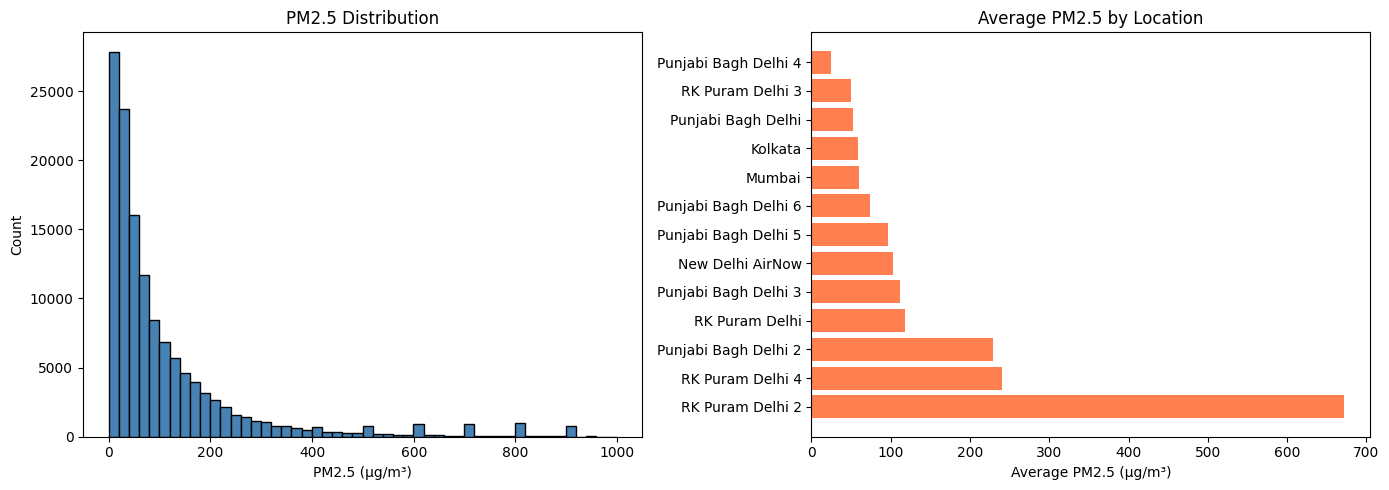

In [19]:
# Save processed data
df.to_csv('../data/air_quality_processed.csv', index=False)
print("Processed data saved! ✅")

# EDA - Basic stats
print("\nPM2.5 Statistics:")
print(df['pm25'].describe())

# Plot PM2.5 distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['pm25'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('PM2.5 Distribution')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Count')

# Average PM2.5 by city
city_avg = df.groupby('city')['pm25'].mean().sort_values(ascending=False)
axes[1].barh(city_avg.index, city_avg.values, color='coral')
axes[1].set_title('Average PM2.5 by Location')
axes[1].set_xlabel('Average PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

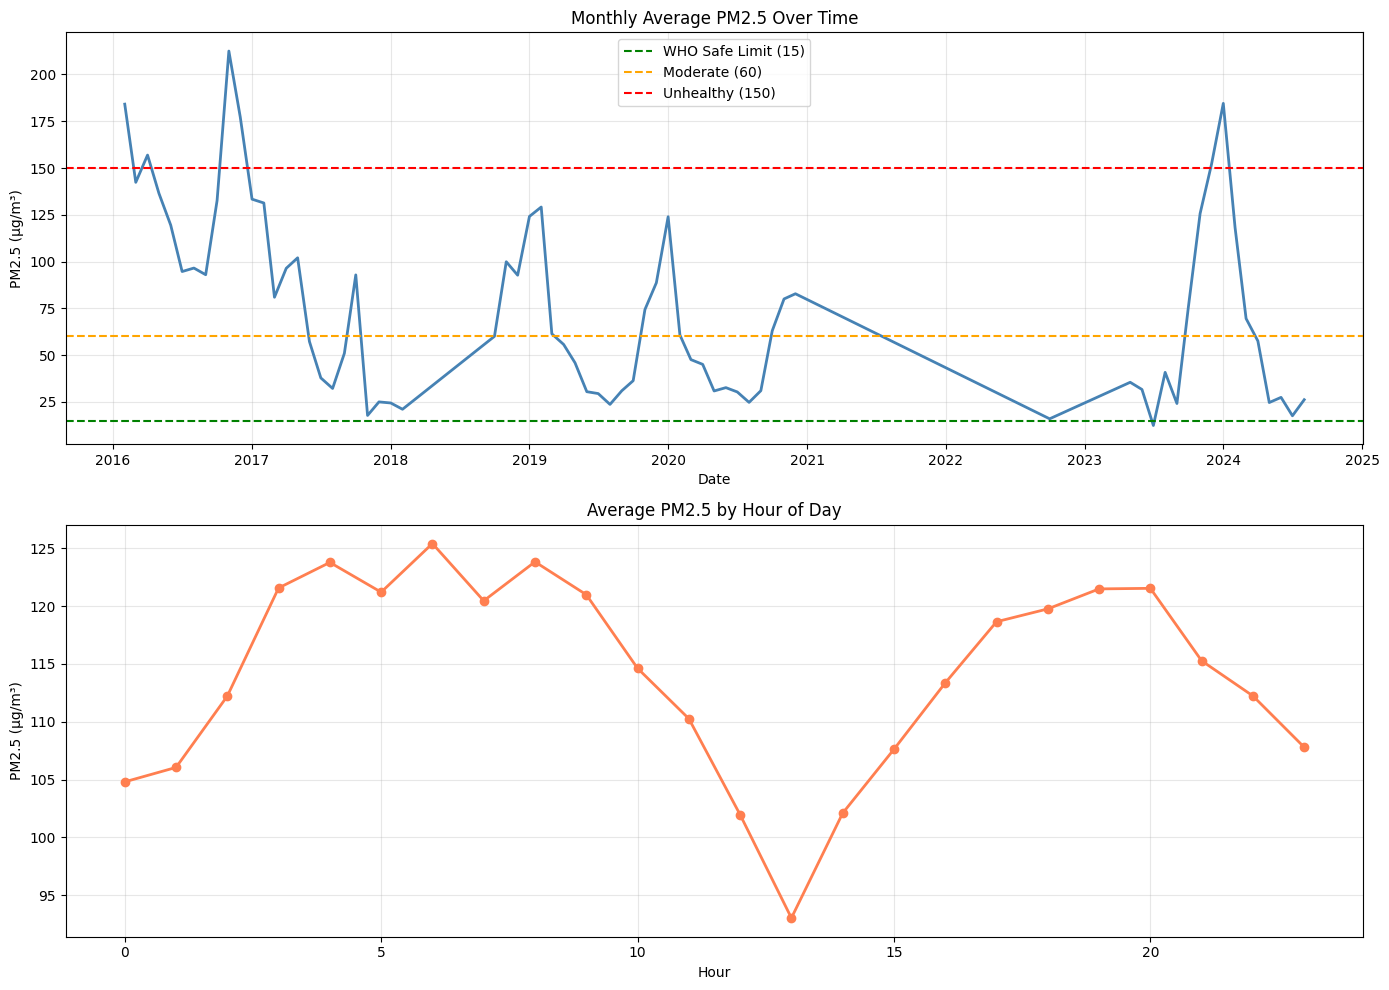

In [20]:
# PM2.5 trend by month
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly average
monthly_avg = df.groupby(['year', 'month'])['pm25'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

axes[0].plot(monthly_avg['date'], monthly_avg['pm25'], color='steelblue', linewidth=2)
axes[0].set_title('Monthly Average PM2.5 Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].axhline(y=15, color='green', linestyle='--', label='WHO Safe Limit (15)')
axes[0].axhline(y=60, color='orange', linestyle='--', label='Moderate (60)')
axes[0].axhline(y=150, color='red', linestyle='--', label='Unhealthy (150)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Average by hour
hourly_avg = df.groupby('hour')['pm25'].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, color='coral', linewidth=2, marker='o')
axes[1].set_title('Average PM2.5 by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])
df['season_encoded'] = le.fit_transform(df['season'])

# Features and target
features = [
    'hour', 'day_of_week', 'month', 'year', 'is_weekend',
    'city_encoded', 'season_encoded',
    'pm25_lag1', 'pm25_lag3', 'pm25_lag6', 'pm25_lag24',
    'pm25_rolling_mean_6', 'pm25_rolling_mean_24', 'pm25_rolling_std_24'
]

X = df[features]
y = df['pm25']

# Temporal split - last 20% as test
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 105932
Test size: 26484


In [22]:
import time
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train Random Forest
print("Training Random Forest...")
start = time.time()
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"✅ Random Forest | MAE: {rf_mae:.2f} | RMSE: {rf_rmse:.2f} | Time: {rf_time:.1f}s")

# Train XGBoost
print("\nTraining XGBoost...")
start = time.time()
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_time = time.time() - start
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"✅ XGBoost | MAE: {xgb_mae:.2f} | RMSE: {xgb_rmse:.2f} | Time: {xgb_time:.1f}s")

# Train Gradient Boosting
print("\nTraining Gradient Boosting...")
start = time.time()
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_time = time.time() - start
gb_pred = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"✅ Gradient Boosting | MAE: {gb_mae:.2f} | RMSE: {gb_rmse:.2f} | Time: {gb_time:.1f}s")

# Summary
print("\n--- Model Comparison ---")
results = {
    'Model': ['Random Forest', 'XGBoost', 'Gradient Boosting'],
    'MAE': [rf_mae, xgb_mae, gb_mae],
    'RMSE': [rf_rmse, xgb_rmse, gb_rmse]
}
results_df = pd.DataFrame(results)
print(results_df)

Training Random Forest...
✅ Random Forest | MAE: 27.68 | RMSE: 55.08 | Time: 15.6s

Training XGBoost...
✅ XGBoost | MAE: 29.71 | RMSE: 56.07 | Time: 3.5s

Training Gradient Boosting...
✅ Gradient Boosting | MAE: 27.09 | RMSE: 52.02 | Time: 95.0s

--- Model Comparison ---
               Model        MAE       RMSE
0      Random Forest  27.680026  55.076386
1            XGBoost  29.708919  56.073154
2  Gradient Boosting  27.091922  52.015796


In [23]:
# Check outliers
print(f"Records above 500 PM2.5: {len(df[df['pm25'] > 500])}")
print(f"Records above 300 PM2.5: {len(df[df['pm25'] > 300])}")
print(f"Records above 200 PM2.5: {len(df[df['pm25'] > 200])}")

# Remove extreme outliers (above 500)
df_clean = df[df['pm25'] <= 500].copy()
print(f"\nOriginal size: {len(df)}")
print(f"Clean size: {len(df_clean)}")

# Retrain with clean data
X_clean = df_clean[features]
y_clean = df_clean['pm25']

split_idx = int(len(df_clean) * 0.8)
X_train = X_clean.iloc[:split_idx]
X_test = X_clean.iloc[split_idx:]
y_train = y_clean.iloc[:split_idx]
y_test = y_clean.iloc[split_idx:]

print(f"\nNew Train size: {len(X_train)}")
print(f"New Test size: {len(X_test)}")

Records above 500 PM2.5: 5286
Records above 300 PM2.5: 11302
Records above 200 PM2.5: 20144

Original size: 132416
Clean size: 127130

New Train size: 101704
New Test size: 25426


In [24]:
# Retrain all models on clean data
print("Training Random Forest...")
start = time.time()
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"✅ Random Forest | MAE: {rf_mae:.2f} | RMSE: {rf_rmse:.2f} | Time: {rf_time:.1f}s")

print("\nTraining XGBoost...")
start = time.time()
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_time = time.time() - start
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"✅ XGBoost | MAE: {xgb_mae:.2f} | RMSE: {xgb_rmse:.2f} | Time: {xgb_time:.1f}s")

print("\nTraining Gradient Boosting...")
start = time.time()
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_time = time.time() - start
gb_pred = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"✅ Gradient Boosting | MAE: {gb_mae:.2f} | RMSE: {gb_rmse:.2f} | Time: {gb_time:.1f}s")

print("\n--- Model Comparison ---")
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Gradient Boosting'],
    'MAE': [rf_mae, xgb_mae, gb_mae],
    'RMSE': [rf_rmse, xgb_rmse, gb_rmse]
})
print(results_df)

Training Random Forest...
✅ Random Forest | MAE: 18.00 | RMSE: 33.00 | Time: 15.0s

Training XGBoost...
✅ XGBoost | MAE: 20.19 | RMSE: 34.53 | Time: 4.2s

Training Gradient Boosting...
✅ Gradient Boosting | MAE: 18.11 | RMSE: 31.80 | Time: 114.2s

--- Model Comparison ---
               Model        MAE       RMSE
0      Random Forest  18.004990  33.000706
1            XGBoost  20.186520  34.532011
2  Gradient Boosting  18.111159  31.799834


In [25]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../models/gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)

with open('../models/label_encoder_city.pkl', 'wb') as f:
    pickle.dump(le, f)

print("All models saved! ✅")

All models saved! ✅
